In [455]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from binance.client import Client
import matplotlib.pyplot as plt
import mplfinance as mpf
import xgboost as xgb
import seaborn as sns
import pandas as pd
import numpy as np
import ta

In [456]:
def get_sharpe_annualization_factor(interval_minutes):
    minutes_per_year = 365 * 24 * 60
    periods_per_year = minutes_per_year / interval_minutes
    return np.sqrt(periods_per_year)

In [457]:
ticker = "BTCUSDT"

hist_data = 7 * 4 * 6 # Six month 

interval = 60 # In minutes

forecast_horizon = 1 

annualize_rate = get_sharpe_annualization_factor(interval) # Sharpe annualize rate 

In [458]:
client = Client("", "")
dict_data = client.get_historical_klines("BTCUSDT", Client.KLINE_INTERVAL_1HOUR, "1 Jan, 2024")

df = pd.DataFrame(dict_data)

df = df.iloc[:, :6]

df.columns = ['Time', 'Open', 'High', 'Low', 'Close', 'Volume']

df['Time'] = pd.to_datetime(df['Time'], unit='ms')

df.set_index('Time', inplace=True)

df = df.apply(pd.to_numeric)

df

,Open,High,Low,Close,Volume
Time,,,,,
2024-01-01 00:00:00,42283.58,42554.57,42261.02,42475.23,1271.68108
2024-01-01 01:00:00,42475.23,42775.00,42431.65,42613.56,1196.37856
2024-01-01 02:00:00,42613.57,42638.41,42500.00,42581.10,685.21980
2024-01-01 03:00:00,42581.09,42586.64,42230.08,42330.49,794.80391
2024-01-01 04:00:00,42330.50,42399.99,42209.46,42399.99,715.41760
...,...,...,...,...,...
2026-03-09 08:00:00,67555.13,67929.19,67391.89,67814.69,1615.43129
2026-03-09 09:00:00,67814.69,68460.09,67566.65,67981.02,1225.43841
2026-03-09 10:00:00,67981.03,68088.92,67556.72,67608.13,687.12244


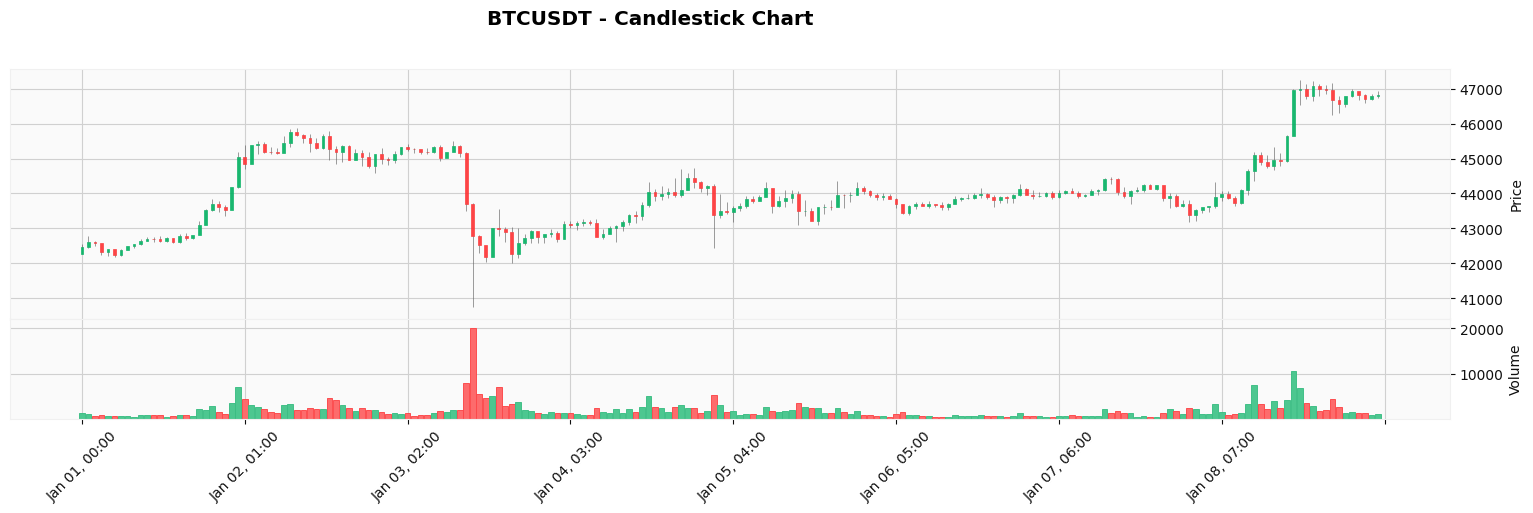

In [459]:
mpf.plot(
    df.head(200),
    type="candle",
    style="yahoo",
    figsize=(20, 5),
    volume=True,
    title=f"{ticker} - Candlestick Chart"
)

### Feature Engineer

In [460]:
def feature_enginering(df : pd.DataFrame) -> pd.DataFrame :
    df["price_change"] = df['Close'].pct_change()
    df["high_low_ratio"] = df['High']/df['Low']
    df["open_close_ratio"] = df['Close']/df['Open']
    df["body_size"] = abs(df['Close'] - df['Open'])

    # Technical indicators (TA-Lib)
    df['rsi'] = ta.momentum.StochRSIIndicator(df['Close'], window=14).stochrsi()
    df['macd'] = ta.trend.MACD(df['Close']).macd()
    df['macd_signal'] = ta.trend.MACD(df['Close']).macd_signal()
    df['bb_upper'] = ta.volatility.BollingerBands(df['Close']).bollinger_hband()
    df['bb_lower'] = ta.volatility.BollingerBands(df['Close']).bollinger_lband()
    df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / df['Close']

    # Volume features
    df['volume_sma'] = df['Volume'].rolling(20).mean()
    df['volume_ratio'] = df['Volume'] / df['volume_sma']
    
    # Lag indicators usefull for small timeframes to have a better overview
    for lag in [1, 3, 6, 12]:  # 5m, 15m, 30m, 1h lags
        df[f'price_lag_{lag}'] = df['Close'].pct_change(lag)
        df[f'rsi_lag_{lag}'] = df['rsi'].shift(lag)
        df[f'volume_lag_{lag}'] = df['Volume'].shift(lag)
    
    # Volatility
    df['volatility'] = df['price_change'].rolling(20).std()
    df['atr'] = ta.volatility.AverageTrueRange(df['High'], df['Low'], df['Close']).average_true_range()
    df['vix_proxy'] = df['Close'].pct_change().rolling(20).std() * np.sqrt(252)

    return df

In [461]:
# Creation of target and lagged values
df["close_log_return"] = np.log(df["Close"]/df["Close"].shift(forecast_horizon))
df


,Open,High,Low,Close,Volume,close_log_return
Time,,,,,,
2024-01-01 00:00:00,42283.58,42554.57,42261.02,42475.23,1271.68108,NaN
2024-01-01 01:00:00,42475.23,42775.00,42431.65,42613.56,1196.37856,0.003251
2024-01-01 02:00:00,42613.57,42638.41,42500.00,42581.10,685.21980,-0.000762
2024-01-01 03:00:00,42581.09,42586.64,42230.08,42330.49,794.80391,-0.005903
2024-01-01 04:00:00,42330.50,42399.99,42209.46,42399.99,715.41760,0.001640
...,...,...,...,...,...,...
2026-03-09 08:00:00,67555.13,67929.19,67391.89,67814.69,1615.43129,0.003835
2026-03-09 09:00:00,67814.69,68460.09,67566.65,67981.02,1225.43841,0.002450
2026-03-09 10:00:00,67981.03,68088.92,67556.72,67608.13,687.12244,-0.005500


In [462]:
target = "close_log_return"
lr = df[target]
lags = [1,2,3,4]

for lag in lags:
    df[f"{target}_lag_{lag}"] = lr.shift(forecast_horizon * lag)

df

,Open,High,Low,Close,Volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
Time,,,,,,,,,,
2024-01-01 00:00:00,42283.58,42554.57,42261.02,42475.23,1271.68108,NaN,NaN,NaN,NaN,NaN
2024-01-01 01:00:00,42475.23,42775.00,42431.65,42613.56,1196.37856,0.003251,NaN,NaN,NaN,NaN
2024-01-01 02:00:00,42613.57,42638.41,42500.00,42581.10,685.21980,-0.000762,0.003251,NaN,NaN,NaN
2024-01-01 03:00:00,42581.09,42586.64,42230.08,42330.49,794.80391,-0.005903,-0.000762,0.003251,NaN,NaN
2024-01-01 04:00:00,42330.50,42399.99,42209.46,42399.99,715.41760,0.001640,-0.005903,-0.000762,0.003251,NaN
...,...,...,...,...,...,...,...,...,...,...
2026-03-09 08:00:00,67555.13,67929.19,67391.89,67814.69,1615.43129,0.003835,0.004272,-0.009528,0.011567,-0.001115
2026-03-09 09:00:00,67814.69,68460.09,67566.65,67981.02,1225.43841,0.002450,0.003835,0.004272,-0.009528,0.011567
2026-03-09 10:00:00,67981.03,68088.92,67556.72,67608.13,687.12244,-0.005500,0.002450,0.003835,0.004272,-0.009528


In [463]:
df = df.dropna()
df

,Open,High,Low,Close,Volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
Time,,,,,,,,,,
2024-01-01 05:00:00,42399.98,42406.00,42180.77,42234.01,736.53152,-0.003922,0.001640,-0.005903,-0.000762,0.003251
2024-01-01 06:00:00,42234.01,42424.82,42208.68,42396.69,601.37250,0.003844,-0.003922,0.001640,-0.005903,-0.000762
2024-01-01 07:00:00,42396.69,42500.00,42396.68,42492.46,653.67718,0.002256,0.003844,-0.003922,0.001640,-0.005903
2024-01-01 08:00:00,42492.46,42556.50,42452.58,42549.99,427.19365,0.001353,0.002256,0.003844,-0.003922,0.001640
2024-01-01 09:00:00,42550.00,42699.32,42537.18,42649.69,879.62491,0.002340,0.001353,0.002256,0.003844,-0.003922
...,...,...,...,...,...,...,...,...,...,...
2026-03-09 08:00:00,67555.13,67929.19,67391.89,67814.69,1615.43129,0.003835,0.004272,-0.009528,0.011567,-0.001115
2026-03-09 09:00:00,67814.69,68460.09,67566.65,67981.02,1225.43841,0.002450,0.003835,0.004272,-0.009528,0.011567
2026-03-09 10:00:00,67981.03,68088.92,67556.72,67608.13,687.12244,-0.005500,0.002450,0.003835,0.004272,-0.009528


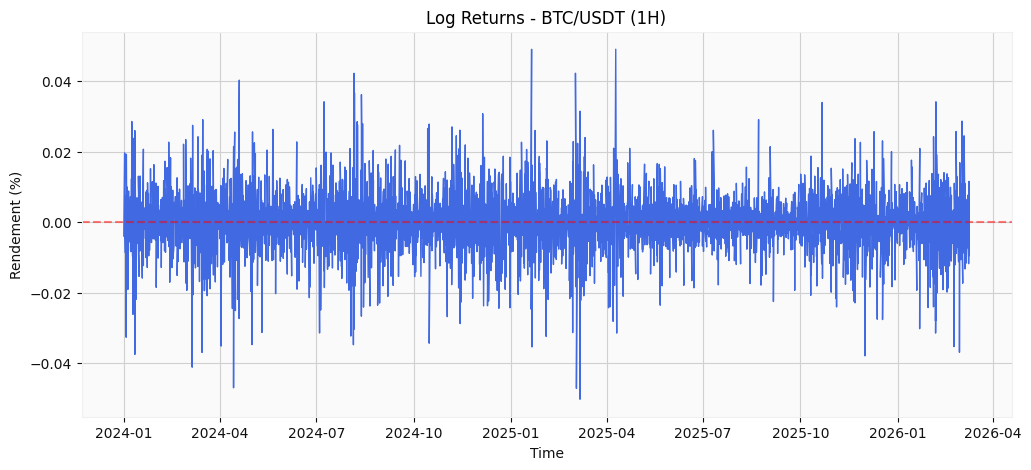

In [464]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=df['close_log_return'], color='royalblue', linewidth=1)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title('Log Returns - BTC/USDT (1H)')
plt.ylabel('Rendement (%)')
plt.show()

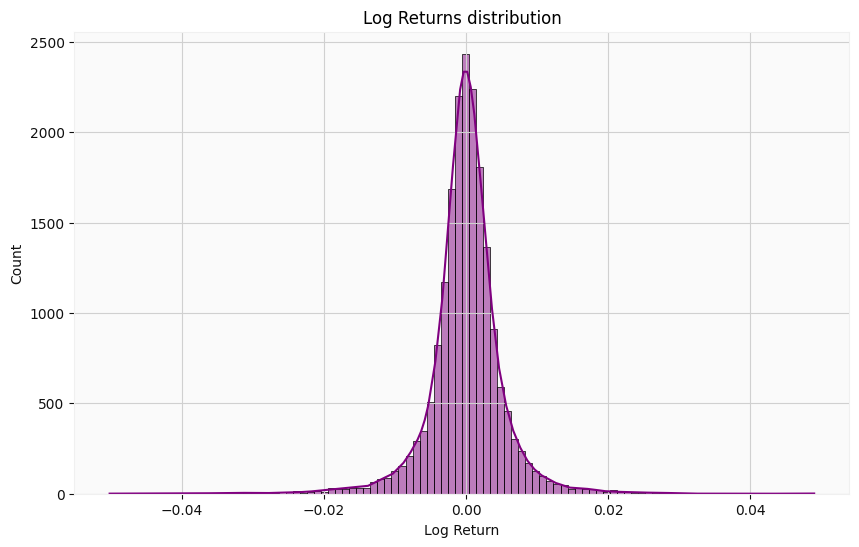

In [465]:
plt.figure(figsize=(10, 6))
sns.histplot(df['close_log_return'].dropna(), kde=True, color='purple', bins=100)
plt.title('Log Returns distribution')
plt.xlabel('Log Return')
plt.show()

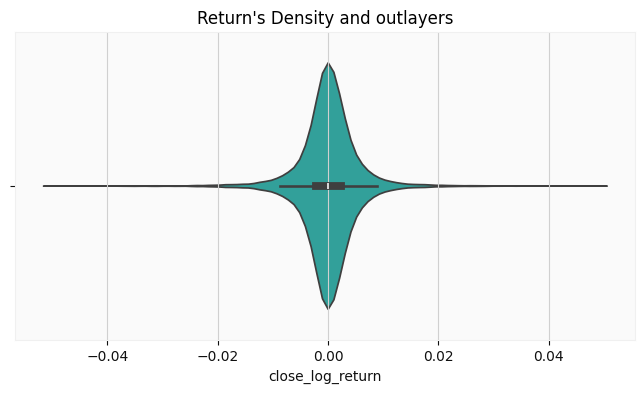

In [466]:
plt.figure(figsize=(8, 4))
sns.violinplot(x=df['close_log_return'], color='lightseagreen')
plt.title("Return's Density and outlayers")
plt.show()

In [467]:
df = feature_enginering(df).dropna()
df

,Open,High,Low,Close,Volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4,...,volume_lag_3,price_lag_6,rsi_lag_6,volume_lag_6,price_lag_12,rsi_lag_12,volume_lag_12,volatility,atr,vix_proxy
Time,,,,,,,,,,,,,,,,,,,,,
2024-01-02 19:00:00,45154.70,45243.00,44790.96,45039.49,2347.28624,-0.002554,0.004184,-0.008673,0.003822,-0.001634,...,3052.23783,-0.013113,0.184672,2253.76868,-0.009153,0.213294,3112.52478,0.006905,404.834053,0.109606
2024-01-02 20:00:00,45039.49,45180.55,44742.96,44788.28,1940.02489,-0.005593,-0.002554,0.004184,-0.008673,0.003822,...,2540.00308,-0.010395,0.000000,4553.21243,-0.021220,0.390630,3323.21707,0.005435,407.173763,0.086273
2024-01-02 21:00:00,44788.27,45119.76,44600.00,45119.74,2043.74183,0.007373,-0.005593,-0.002554,0.004184,-0.008673,...,1806.07730,-0.001440,0.000000,4301.03657,-0.012124,0.145380,2096.46195,0.005601,415.215637,0.088906
2024-01-02 22:00:00,45119.74,45297.26,44840.01,44981.73,1591.57491,-0.003063,0.007373,-0.005593,-0.002554,0.004184,...,2347.28624,-0.008292,0.099431,3052.23783,-0.013234,0.000000,2069.22249,0.004961,418.218092,0.078752
2024-01-02 23:00:00,44981.72,45049.98,44802.01,44946.91,1080.22719,-0.000774,-0.003063,0.007373,-0.005593,-0.002554,...,1940.02489,-0.000428,0.000000,2540.00308,-0.010721,0.000000,2538.49307,0.004956,406.057514,0.078680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-09 08:00:00,67555.13,67929.19,67391.89,67814.69,1615.43129,0.003835,0.004272,-0.009528,0.011567,-0.001115,...,1145.71148,0.019198,0.650229,752.57114,0.008565,0.519828,1144.93227,0.006130,637.263175,0.097314
2026-03-09 09:00:00,67814.69,68460.09,67566.65,67981.02,1225.43841,0.002450,0.003835,0.004272,-0.009528,0.011567,...,578.70307,0.011546,1.000000,1256.29482,0.014339,0.327836,959.03531,0.006133,655.561519,0.097357
2026-03-09 10:00:00,67981.03,68088.92,67556.72,67608.13,687.12244,-0.005500,0.002450,0.003835,0.004272,-0.009528,...,1253.45589,0.007120,0.951006,848.47762,0.020703,0.000000,2742.02435,0.006274,646.749982,0.099593


Standardisation

In [468]:
y = df["close_log_return"]
dataset = df.drop(columns=["close_log_return"])

scaler = StandardScaler()

X = pd.DataFrame(
    index=df.index,
    data=scaler.fit_transform(dataset,target)
)

In [ ]:
n_samples = len(X)
test_size = int(n_samples * 0.25)

tscv = TimeSeriesSplit(n_splits=2, test_size=test_size)

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

In [470]:
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 6, 8, 10],
    'learning_rate': [0.001, 0.01, 0.05, 0.1],
    'subsample' : [0.5, 0.6, 0.7, 0.8],
    'colsample_bytree' : [0.5, 0.6, 0.7, 0.8],
    'reg_lambda' : [1.0],
    'reg_alpha' : [0.1]
}

model = xgb.XGBRFRegressor(
    eval_metric='rmse',
    random_state=42
)

grid_search = GridSearchCV(
    estimator=model, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 1600 candidates, totalling 8000 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRFRegresso...state=42, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.5, 0.6, ...], 'learning_rate': [0.001, 0.01, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computa

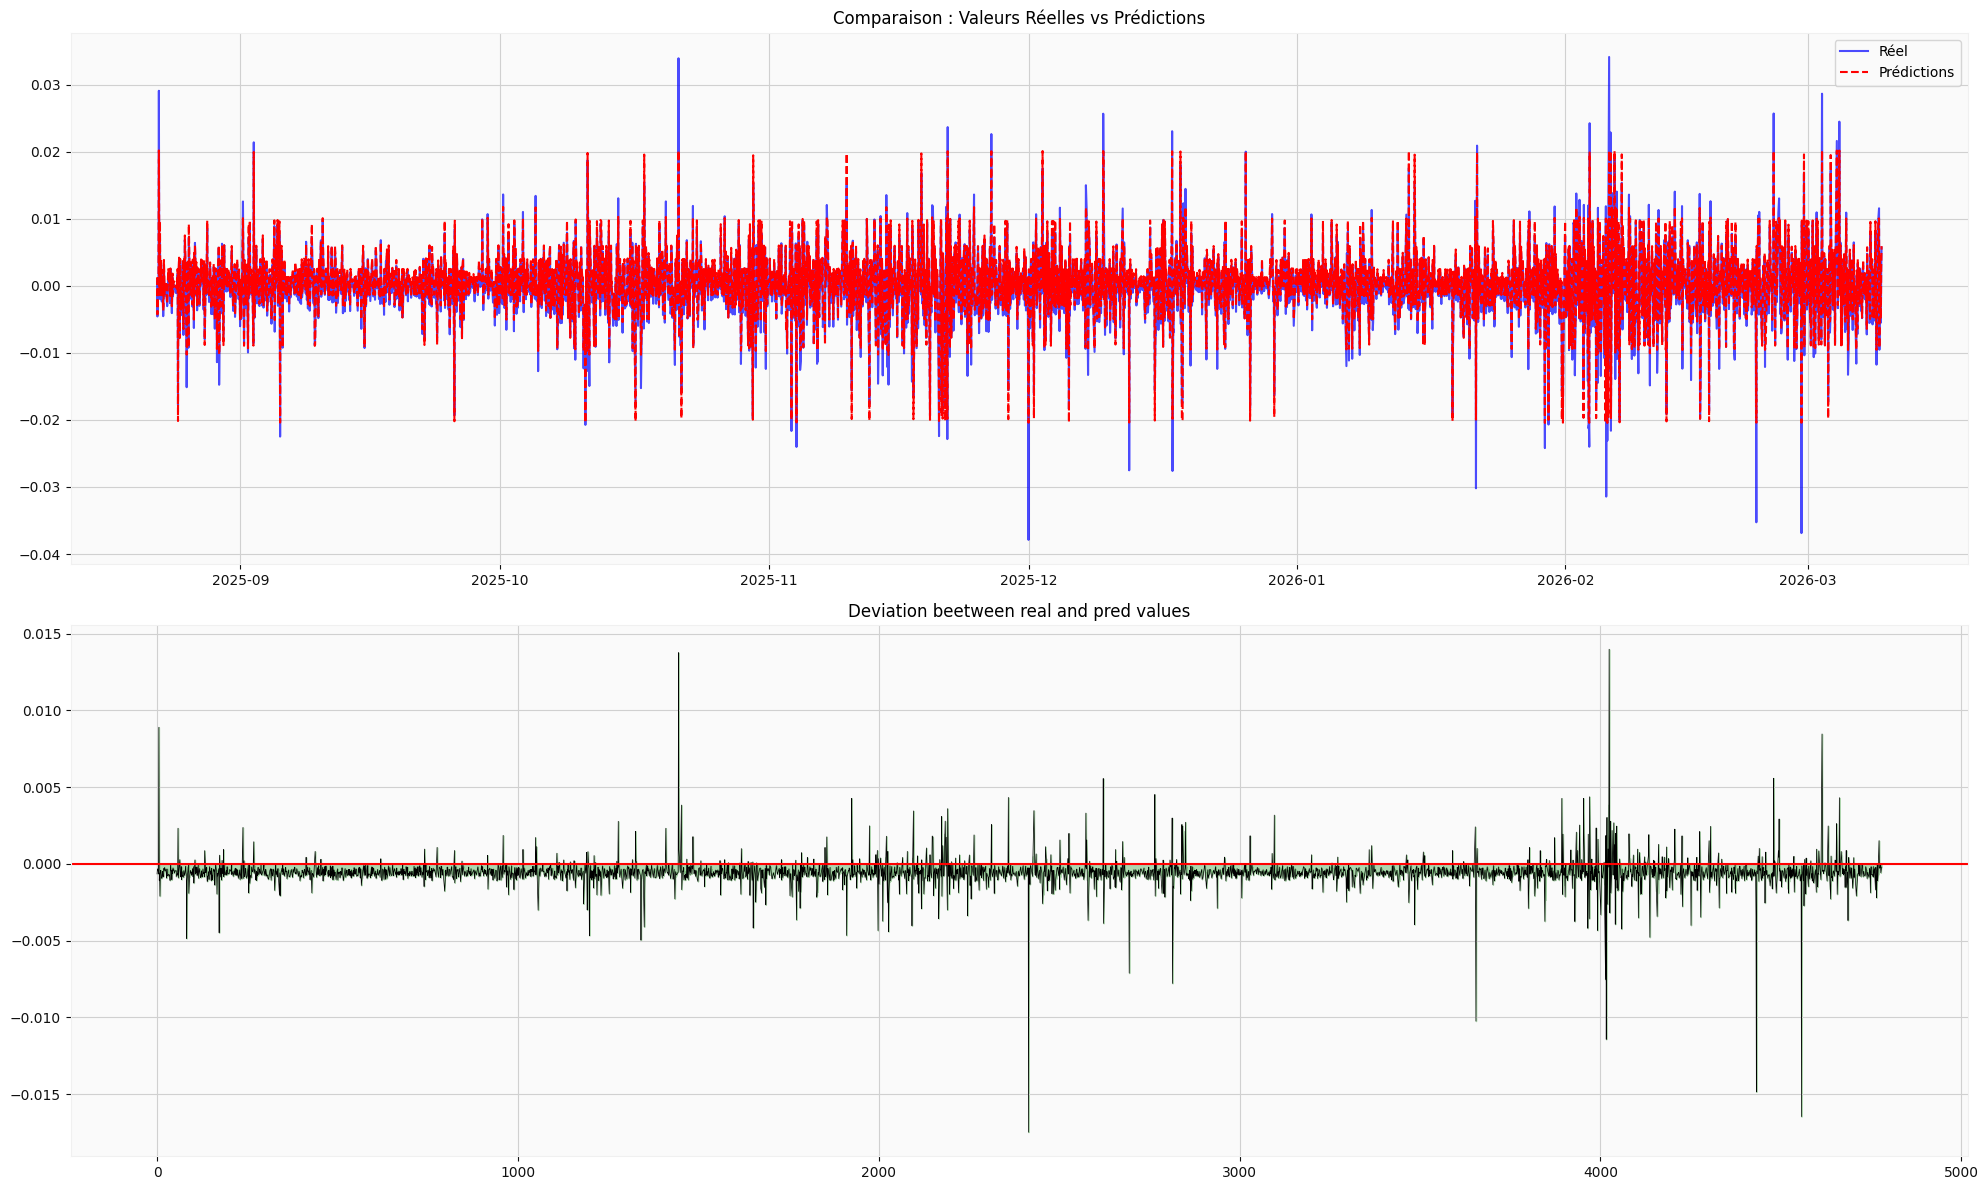

In [ ]:
predictions = pd.DataFrame(
    index=X_test.index,
    data = grid_search.predict(X_test)*10
    )

y_real = y_test.values.flatten()
y_pred = predictions.values.flatten()
residuals = y_real - y_pred
indices = range(len(residuals))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 12))

ax1.plot(y_test.index, y_real, label='Réel', color='blue', alpha=0.7)
ax1.plot(y_test.index, y_pred, label='Prédictions', color='red', linestyle='--')
ax1.set_title("Reel Values vs Predictions")
ax1.legend()

ax2.fill_between(indices, residuals, 0, color='green', alpha=0.3)
ax2.plot(indices, residuals, color='black', linewidth=0.5)
ax2.set_title("Deviation beetween real and pred values")
ax2.axhline(0, color='red', linestyle='-')

plt.tight_layout()
plt.show()